In [1]:
import tidy3d as td
import numpy as np
import tidy3d.web as web
import matplotlib.pyplot as plt
import gdstk
import os

In [2]:
wg_height = 0.22
spot_size = 10.4
box_thick = 2.0
clad_thick = 0.78
sub_height = 0.8
etch_dep = 0.09

# Define wavelength and frequency parameters
wl_c = 1.55
wl_bw = 0.06
wl_n = 61
wl_min = wl_c-wl_bw/2
wl_max = wl_c+wl_bw/2
freq_c = td.C_0/wl_c
freq_min = td.C_0/wl_max
freq_max = td.C_0/wl_min
freq_bw = freq_max - freq_min
wls = np.linspace(wl_min, wl_max, wl_n)
freqs = td.C_0/wls
# print(freq_bw)

tilt_angle = 14.5 # Tilt angle in degrees
tilt_angle_rad = np.radians(tilt_angle)

tbp_gaussian = 0.441 # Time bandwidth product for Gaussian pulse
pulse_dur = tbp_gaussian/freq_bw # Pulse duration in seconds

# Set simulation paddings
pad_x = 1*wl_c
pad_y = 1*wl_c
pad_z = 2*wl_c
run_time = 2e-12  # Run time parameter for simulation (s).

# Define media
n_sio2 =  1.44
n_si = 3.48  # Silicon refractive index.

Vacuum = td.Medium(
    name = 'Vacuum', 
)

si = td.Medium(
    name = 'Si', 
    permittivity = n_si**2, 
)

SiO2 = td.Medium(
    name = 'SiO2', 
    permittivity = n_sio2**2, 
)

In [3]:
# Get design cell from GDSII file
gds_path  = r'misc/Focusing_GC.gds'  # File name to export GC GDS file.
lib_loaded = gdstk.read_gds(gds_path)
all_cells = {c.name: c for c in lib_loaded.cells}
print("Cell names: " + ", ".join(all_cells.keys()))
des_cell = all_cells["GC"]
print(des_cell)

# Create geometry from GDS cell
wg_geo = td.Geometry.from_gds(
    des_cell,
    gds_layer=3,
    gds_dtype=3,
    axis=2,
    slab_bounds=(0, wg_height),
    reference_plane = "bottom",
)

radial_etch_geo = td.Geometry.from_gds(
    des_cell,
    gds_layer=2,
    gds_dtype=2,
    axis=2,
    slab_bounds=(0, etch_dep),
    reference_plane = "bottom",
)

radial_no_etch_geo = td.Geometry.from_gds(
    des_cell,
    gds_layer=1,
    gds_dtype=1,
    axis=2,
    slab_bounds=(0, wg_height),
    reference_plane = "bottom",
)

# Adjust offset of design geometry
move_by = td.Transformed.translation(-wg_geo.bounds[0][0]+pad_x/2, 0, -wg_height/2)
wg_geo = td.Transformed(geometry=wg_geo, 
                    transform=move_by)  

move_by = td.Transformed.translation((wg_geo.bounds[1][0]-wg_geo.bounds[0][0])-radial_etch_geo.bounds[0][0]+pad_x/2-0.687, 0, -wg_height/2)
radial_etch_geo = td.Transformed(geometry=radial_etch_geo,
                             transform=move_by)
                                                   
move_by = td.Transformed.translation((wg_geo.bounds[1][0]-wg_geo.bounds[0][0])-radial_no_etch_geo.bounds[0][0]+pad_x/2-0.687, 0, -wg_height/2)
radial_no_etch_geo = td.Transformed(geometry=radial_no_etch_geo,
                                transform=move_by)

des_len  = (wg_geo.bounds[1][0] - wg_geo.bounds[0][0]) + (radial_etch_geo.bounds[1][0] - radial_etch_geo.bounds[0][0])
des_wid  = (wg_geo.bounds[1][1] - wg_geo.bounds[0][1]) + (radial_etch_geo.bounds[1][1] - radial_etch_geo.bounds[0][1])
center_x = pad_x/2 + des_len/2

# Create design structure
wg = td.Structure(
    geometry=wg_geo,
    medium=si,
    name="Design",
)

# Create etch structure
radial_etch = td.Structure(
    geometry=radial_etch_geo,
    medium=si,
    name="Etch",
)

# Create no-etch structure
radial_no_etch = td.Structure(
    geometry=radial_no_etch_geo,
    medium=si,
    name="No-etch",
)

# Create box structure
box = td.Structure(
    geometry=td.Box(
        center=(center_x, 0, -box_thick/2-wg_height/2), 
        size=(des_len, des_wid + 4, box_thick),
    ),
    medium=SiO2,
    name="Box",
)

# Create clad structure
clad = td.Structure(
    geometry=td.Box(
        center=(center_x, 0, clad_thick/2-wg_height/2), 
        size=(des_len, des_wid + 4, clad_thick),
    ),
    medium=SiO2,
    name="Clad",
)

# Create substrate structure
sub = td.Structure(
    geometry=td.Box(
        center=(center_x, 0, -box_thick/2-wg_height/2-sub_height/2), 
        size=(des_len, des_wid + 4, sub_height),
    ),
    medium=si,
    name="Substrate",
)


print(wg.geometry.bounds)
print(radial_etch.geometry.bounds)
print(radial_no_etch.geometry.bounds)
print(box.geometry.bounds)
print(clad.geometry.bounds)
print(sub.geometry.bounds)

# # Plot design geometry at z=0
# wg_geo.plot(z=0)
# radial_etch_geo.plot(z=0)
# radial_no_etch_geo.plot(z=0)
# box.plot(z=0)
# clad.plot(z=0)
# sub.plot(z=0)

Cell names: GC
Cell 'GC' with 29 polygons, 0 flexpaths, 0 robustpaths, 0 references, and 0 labels
((0.7750000000000004, -0.25, -0.11), (16.775, 0.25, 0.11))
((16.087999999999997, -11.273, -0.11), (49.047, 11.273, -0.020000000000000004))
((16.087999999999997, -11.273, -0.11), (49.047, 11.273, 0.11))
((0.7749999999999986, -13.523, -2.1100000000000003), (49.734, 13.523, -0.1100000000000001))
((0.7749999999999986, -13.523, -0.10999999999999999), (49.734, 13.523, 0.67))
((0.7749999999999986, -13.523, -1.9100000000000001), (49.734, 13.523, -1.1100000000000003))


In [13]:
src_offset_x = 10.0
src_offset_y = 0.0
src_offset_z = 0.0

gaussian_source = td.GaussianBeam(
    name = 'gaussian_source', 
    center = [des_len-src_offset_x, 0, clad_thick+wg_height/2+src_offset_z], 
    size = [1.2*spot_size, 1.2*spot_size, 0], 
    source_time = td.GaussianPulse(freq0 = freq_c,
                                   fwidth = freq_bw, ), 
    pol_angle=np.pi / 2, # Polarization angle
    direction = '-', # Pointing down in z
    angle_theta = tilt_angle_rad, 
    waist_radius = 0.5*spot_size, 
)

xy_field = td.FieldMonitor(
    name = 'xy_field', 
    center = [center_x, 0, 0], 
    size = [des_len, des_wid+pad_y, 0], 
    freqs = freq_c, 
)

output_mode = td.ModeMonitor(
    name = 'output_mode', 
    center = [pad_x/2, 0, 0], 
    size = [0, 5, 5], 
    freqs = np.linspace(freq_min, freq_max, wl_n),
    mode_spec = td.ModeSpec(target_neff = n_si, 
                            filter_pol = 'te', ), 
)

Simulation size: 52.059 26.146 6.42


18:09:21 Eastern Daylight Time WARNING: A bound of Simulation.structures[0] was 
                               detected as being within the simulation PML. We  
                               recommend extending structures to infinity or    
                               completely outside of the simulation PML to avoid
                               unexpected effects when the structures are not   
                               translationally invariant within the PML.        

                               WARNING: Suppressed 2 WARNING messages.          

<Axes: title={'center': 'cross section at y=0.00'}, xlabel='x', ylabel='z'>

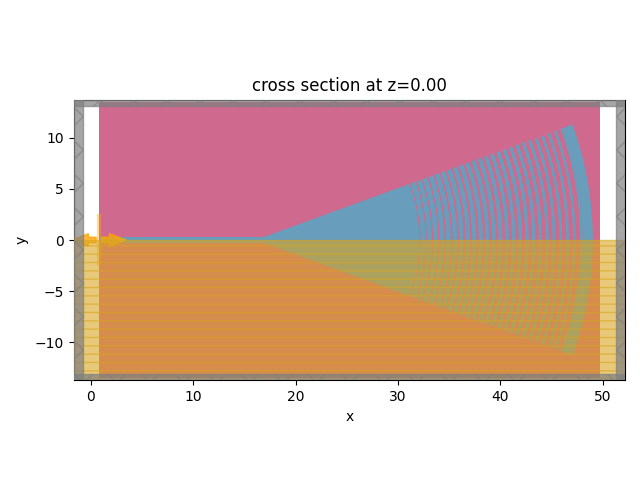

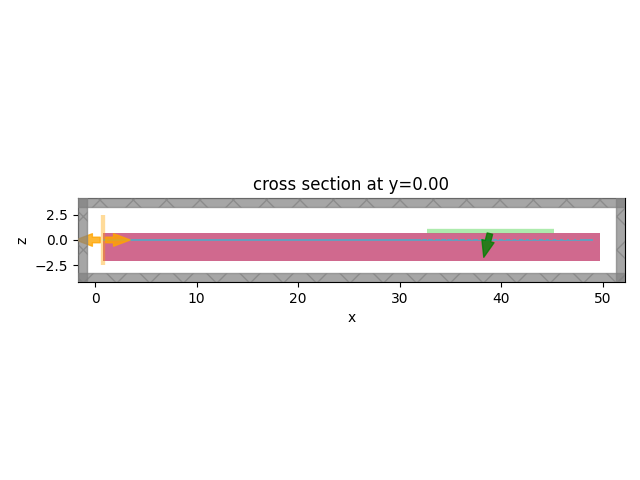

In [14]:
%matplotlib widget

# Set simulation domain size
size_x = pad_x + des_len + pad_x
size_y = pad_y + des_wid + pad_y
size_z = pad_z + wg_height + pad_z
print("Simulation size:", size_x, size_y, size_z)
ng_guess = 2.0
run_time = 1.5*(des_len*ng_guess/td.C_0 + pulse_dur)

# Refine the grid over the GC region.
refine_box = td.MeshOverrideStructure(
    geometry=td.Box(center=(size_x / 2, 0, 0), 
                    size=(td.inf, 
                          td.inf,
                          2 * wg_height)),
    dl=[0.02, 0.02, 0.02],
)

sim = td.Simulation(
    center = [center_x, 0, 0], 
    size = [size_x, size_y, size_z],
    run_time = run_time, 
    symmetry = [0, -1, 0], 
    grid_spec = td.GridSpec(grid_x = td.AutoGrid(min_steps_per_wvl = 20, ),
                            grid_y = td.AutoGrid(min_steps_per_wvl = 20, ), 
                            grid_z = td.AutoGrid(min_steps_per_wvl = 20, ), 
                            wavelength = wl_c,
                            # override_structures=[refine_box],
                            ), 
    subpixel = td.SubpixelSpec(dielectric = td.PolarizedAveraging(), 
                               metal = td.Staircasing(), 
                               pec = td.PECConformal(timestep_reduction = 0.3), ), 
    boundary_spec=td.BoundarySpec(
        x=td.Boundary.pml(),
        y=td.Boundary.pml(),
        z=td.Boundary.pml(),
    ),                               
    medium = Vacuum,
    sources = [gaussian_source],
    monitors = [output_mode],
    structures = [sub, box, clad, wg, radial_no_etch, radial_etch],
)

sim.plot(z = 0)
sim.plot(y = 0)

In [15]:
job = web.Job(simulation=sim, task_name="gc_in_coupling_3d", verbose=False)
sim_3d_in = job.run(path="data/gc3d_in_data.hdf5")

18:09:31 Eastern Daylight Time WARNING: A bound of Simulation.structures[0] was 
                               detected as being within the simulation PML. We  
                               recommend extending structures to infinity or    
                               completely outside of the simulation PML to avoid
                               unexpected effects when the structures are not   
                               translationally invariant within the PML.        

                               WARNING: Suppressed 2 WARNING messages.          

18:11:16 Eastern Daylight Time WARNING: A bound of Simulation.structures[0] was 
                               detected as being within the simulation PML. We  
                               recommend extending structures to infinity or    
                               completely outside of the simulation PML to avoid
                               unexpected effects when the structures are not   
                               translationally invariant within the PML.        

                               WARNING: Suppressed 2 WARNING messages.          

                               WARNING: Simulation final field decay value of   
                               0.049 is greater than the simulation shutoff     
                               threshold of 1e-05. Consider running the         
                               simulation again with a larger 'run_time'        
                               duration for more accurate results.              

                               WARNING: Warning messages were found in the      
                               solver log. For more information, check          
                               'SimulationData.log' or use                      
                               'web.download_log(task_id)'.                     

Text(0.5, 1.0, 'Maximum CE: -29.968 dB')

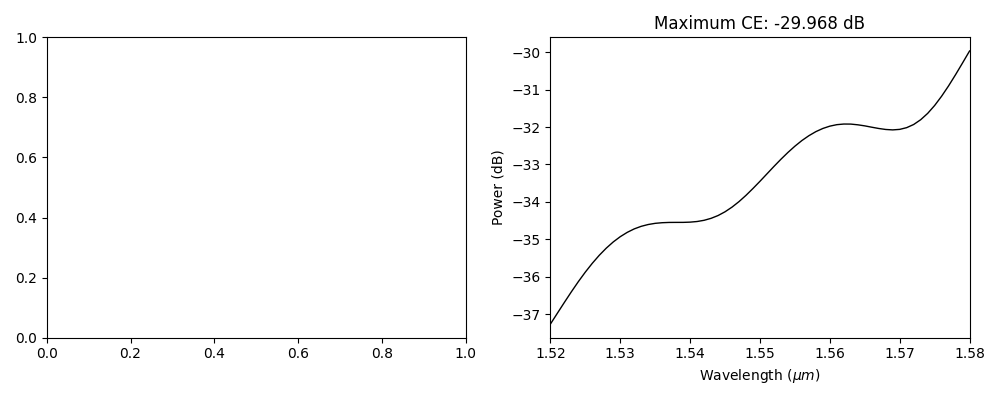

In [17]:
# Coupling Efficiency
mode_amps = sim_3d_in["output_mode"]
coeffs_f = mode_amps.amps.sel(direction="-")
power = np.abs(coeffs_f.sel(mode_index=0)) ** 2
power_db = 10 * np.log10(power)
ce_3d = np.amax(power_db)
# # Fluxes
# power_sub = abs(sim_3d_in["flux_sub"].flux)
# power_ref = abs(sim_3d_in["flux_reflected"].flux)

fig, (ax1, ax2) = plt.subplots(1, 2, tight_layout=True, figsize=(10, 4))
plt.plot(wls, power_db, color="black", linestyle="solid", linewidth=1.0)
plt.xlim([wls[0], wls[-1]])
plt.xlabel("Wavelength ($\mu m$)")
plt.ylabel("Power (dB)")
plt.title(f"Maximum CE: {ce_3d:.3f} dB")
# ax2.plot(
#     wl_range,
#     power_sub,
#     color="black",
#     linestyle="solid",
#     linewidth=1.0,
#     label="substrate",
# )
# ax2.plot(
#     wl_range,
#     power_ref,
#     color="red",
#     linestyle="solid",
#     linewidth=1.0,
#     label="reflected",
# )
# ax2.set_xlim([wl_range[0], wl_range[-1]])
# ax2.set_xlabel("Wavelength ($\mu m$)")
# ax2.set_ylabel("Power (W)")
# ax2.legend()
# plt.show()

KeyError: 'xy_field'

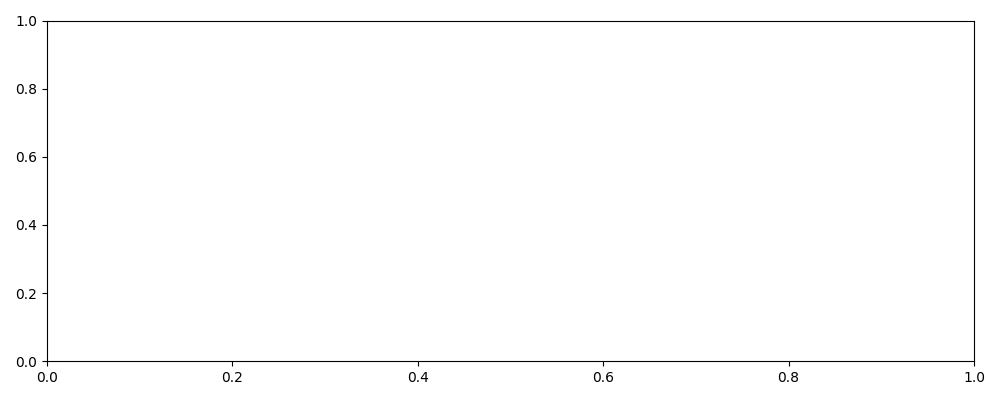

In [18]:
fig, ax = plt.subplots(1, 1, tight_layout=True, figsize=(10, 4))
sim_3d_in.plot_field("xy_field", "E", f=freq_c, val="abs", ax=ax)
# sim_3d_in.plot_field("field_xz", "E", f=freq_c, val="abs", ax=ax2)
ax.set_aspect("auto")
plt.show()